In [8]:
#trials of different outlier tools#
!pip install trackpy --no-deps

!pip install pandas scipy matplotlib pims looseversion




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pims: filename=pims-0.7-py3-none-any.whl size=84644 sha256=68cc108a48a8d1e4fb3cb9ae96836514ac60f6817a583f01b14cce05d870938d
  Stored in directory: /home/msadeck/.cache/pip/wheels/19/dc/d2/e872d34a5e460ff64d2f916938044498fc123855a68318b9d5
Successfully built pims
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pims]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# === Imports ===

import os
import numpy as np
import pandas as pd
from skimage.io import imread
from skimage.measure import label, regionprops, regionprops_table
import matplotlib.pyplot as plt
import trackpy as tp
from tqdm import tqdm
from IPython.display import Video

In [23]:
#upload data and extract diameter and intensities#
# === Extract equivalent diameter and mean intensity for all masks ===
czi_filename = 'mix_dilution_FibronectinPDK_24hr_5x_1x_JDF_9may2025-Scene-30-E4-E04/'
mask_dir = czi_filename + 'cellpose_outputs2'
image_dir = czi_filename + 'raw_rgb_frames'

# List directories of all masks and RGB files
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('_mask.tif')])
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png') or f.endswith('.tif')])

# === List to collect all objects ===
all_points = []

import os
from skimage.io import imread

for f in mask_files:
    try:
        _ = imread(os.path.join(mask_dir, f))
    except Exception as e:
        print(f"⚠️ Problem reading {f}: {e}")

from skimage.io import imread
from skimage.measure import label, regionprops
import pandas as pd
from tqdm import tqdm
import os

all_points = []

for frame_num, (mask_fname, image_fname) in enumerate(tqdm(zip(mask_files, image_files), total=len(mask_files))):
    mask_path = os.path.join(mask_dir, mask_fname)
    image_path = os.path.join(image_dir, image_fname)

    try:
        mask = imread(mask_path)
        image = imread(image_path)
    except Exception as e:
        print(f"⚠️ Skipping {mask_fname}: {e}")
        continue

    # Convert to grayscale if RGB
    if image.ndim == 3:
        image = image.mean(axis=-1)

    regions = regionprops(label(mask), intensity_image=image)

    for r in regions:
        y, x = r.centroid
        all_points.append({
            'frame': frame_num,
            'y': y, 'x': x,
            'area': r.area,
            'solidity': r.solidity,
            'equivalent_diameter': r.equivalent_diameter,
            'mean_intensity': r.mean_intensity,
            'max_intensity': r.max_intensity,
            'min_intensity': r.min_intensity,
            'orientation': r.orientation,
            'eccentricity': r.eccentricity,
            'perimeter': r.perimeter,
            'major_axis_length': r.major_axis_length,
            'minor_axis_length': r.minor_axis_length
        })

full_df = pd.DataFrame(all_points)


100%|██████████| 289/289 [01:06<00:00,  4.33it/s]


In [24]:


# === Loop through all image/mask pairs ===
for frame_num, (mask_fname, image_fname) in enumerate(tqdm(zip(mask_files, image_files), total=len(mask_files))):
    mask = imread(os.path.join(mask_dir, mask_fname))
    image = imread(os.path.join(image_dir, image_fname))
    
    # Convert to grayscale if RGB
    if image.ndim == 3:
        image = image.mean(axis=-1)

    # Label and extract region properties
    regions = regionprops(label(mask), intensity_image=image)

    for r in regions:
        y, x = r.centroid
        all_points.append({
            'frame': frame_num,
            'y': y,
            'x': x,
            'area': r.area,
            'solidity': r.solidity,
            'equivalent_diameter': r.equivalent_diameter,
            'mean_intensity': r.mean_intensity,
            'max_intensity': r.max_intensity,
            'min_intensity': r.min_intensity,
            'orientation': r.orientation,
            'eccentricity': r.eccentricity,
            'perimeter': r.perimeter,
            'major_axis_length': r.major_axis_length,
            'minor_axis_length': r.minor_axis_length
        })

# === Convert to DataFrame ===
full_df = pd.DataFrame(all_points)




100%|██████████| 289/289 [01:06<00:00,  4.37it/s]


In [25]:
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Assume df has columns: frame, x, y, and possibly others
max_distance = 15  # max allowed distance between detections in consecutive frames

# New filtered list of rows to keep
rows_to_keep = []

# Sort the DataFrame by frame
df_sorted = full_df.sort_values('frame')

# Loop over frames
for f in sorted(df_sorted['frame'].unique()):
    df_curr = df_sorted[df_sorted['frame'] == f]

    if f == 0:
        # Always keep first frame
        rows_to_keep.append(df_curr)
        continue

    df_prev = df_sorted[df_sorted['frame'] == f - 1]

    # Skip if no data in previous frame
    if df_prev.empty:
        continue

    prev_coords = df_prev[['x', 'y']].values
    curr_coords = df_curr[['x', 'y']].values

    # Build KD-tree and query distances
    tree = cKDTree(prev_coords)
    distances, _ = tree.query(curr_coords, k=1)

    # Keep only those within the distance threshold
    df_curr_filtered = df_curr[distances <= max_distance]
    rows_to_keep.append(df_curr_filtered)

# Concatenate all kept rows
tree_df = pd.concat(rows_to_keep, ignore_index=True)


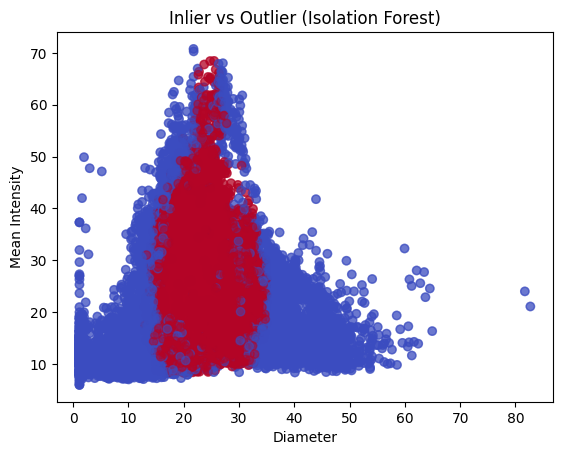

In [26]:
from sklearn.ensemble import IsolationForest

# === 1. Choose frames to use for training (e.g., first 20 frames) ===
n_train_frames = 100
train_df = full_df[full_df['frame'] < n_train_frames]

# === 2. Define the feature columns to use ===
feature_cols = [
    'equivalent_diameter',
    'mean_intensity',
    'area',
    'solidity',
    'eccentricity',
    'perimeter',
    'major_axis_length',
    'minor_axis_length'
]

# Optional: Drop rows with NaNs in any selected feature
train_df = train_df.dropna(subset=feature_cols)
full_df = full_df.dropna(subset=feature_cols)

# === 3. Fit Isolation Forest on training data ===
X_train = train_df[feature_cols].values
X_all = full_df[feature_cols].values

iso_forest = IsolationForest(contamination='auto', random_state=42)
iso_forest.fit(X_train)

# === 4. Apply to all data ===
# Output: -1 = outlier, 1 = inlier
full_df['outlier'] = iso_forest.predict(X_all)
full_df['inlier_mask'] = full_df['outlier'] == 1

import matplotlib.pyplot as plt

plt.scatter(full_df['equivalent_diameter'], full_df['mean_intensity'],
            c=full_df['inlier_mask'], cmap='coolwarm', alpha=0.5)
plt.xlabel('Diameter')
plt.ylabel('Mean Intensity')
plt.title('Inlier vs Outlier (Isolation Forest)')
plt.show()

subset_df = full_df[full_df['inlier_mask']]


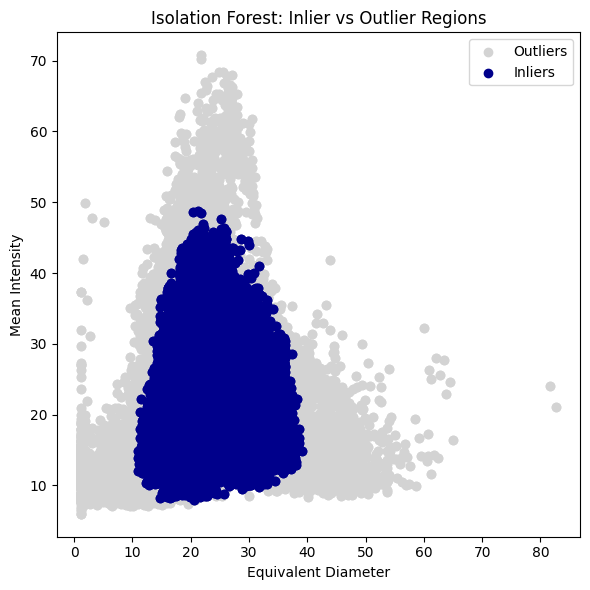

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# === 1. Choose features from the DataFrame ===
# You can modify this list to use different features!
feature_cols = [
    'area',
    'solidity',
    'equivalent_diameter',
    'mean_intensity',
    'max_intensity',
    'min_intensity',
    'orientation',
    'eccentricity',
    'perimeter',
    'major_axis_length',
    'minor_axis_length'

]


# Drop rows with missing data in these columns (just in case)
df_clean = full_df

# Extract feature array
X = df_clean[feature_cols].values

# === 2. Normalize features (recommended for Isolation Forest) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === 3. Train Isolation Forest ===
iso_forest = IsolationForest(contamination='auto', random_state=42)
inlier_mask = iso_forest.fit_predict(X_scaled) == 1  # 1 = inlier, -1 = outlier

# === 4. Get filtered DataFrame and raw values ===
inliers = df_clean[inlier_mask]
outliers = df_clean[~inlier_mask]

# === 5. (Optional) Visualize with two selected dimensions ===
# You can choose any two of your selected features for plotting
x_feat = 'equivalent_diameter'
y_feat = 'mean_intensity'

plt.figure(figsize=(6, 6))
plt.scatter(df_clean[x_feat], df_clean[y_feat], c='lightgray', label='Outliers')
plt.scatter(inliers[x_feat], inliers[y_feat], c='darkblue', label='Inliers')
plt.xlabel(x_feat.replace('_', ' ').title())
plt.ylabel(y_feat.replace('_', ' ').title())
plt.title("Isolation Forest: Inlier vs Outlier Regions")
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
#globally trained isolation forest
from sklearn.ensemble import IsolationForest

# === 1. Construct feature array for outlier detection ===
features = np.column_stack((diameter_list, intensity_list, area_list, solidity_list))

# === 2. Train Isolation Forest ===
iso_forest = IsolationForest(contamination='auto', random_state=42)
inlier_mask = iso_forest.fit_predict(features) == 1  # 1 = inlier, -1 = outlier

# === 3. Filter the features to get thresholds for visualization/debugging (optional) ===
filtered_diameters = np.array(diameter_list)[inlier_mask]
filtered_intensities = np.array(intensity_list)[inlier_mask]

# === 4. Visualize what was kept ===
plt.figure(figsize=(6, 6))
plt.scatter(diameter_list, intensity_list, c='lightgray', label='Outliers')
plt.scatter(filtered_diameters, filtered_intensities, c='darkblue', label='Inliers')
plt.xlabel("Equivalent Diameter")
plt.ylabel("Mean Intensity")
plt.title("Isolation Forest: Inlier vs Outlier Regions")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'diameter_list' is not defined

In [29]:
from sklearn.ensemble import IsolationForest

# Feature columns
feature_cols = [
    'area',
    'solidity',
    'equivalent_diameter',
    'mean_intensity',
    'max_intensity',
    'min_intensity',
    'orientation',
    'eccentricity',
    'perimeter',
    'major_axis_length',
    'minor_axis_length'

]

# Convert to DataFrame
df_window_filtered = pd.DataFrame(all_points)
df_window_filtered['is_inlier'] = True

window_radius = 20
total_frames = df_window_filtered['frame'].max()

for current_frame in tqdm(range(total_frames + 1), desc="Running Isolation Forest per frame"):
    # Frame window
    window_start = max(0, current_frame - window_radius)
    window_end = min(total_frames, current_frame + window_radius)

    df_window = df_window_filtered[
        (df_window_filtered['frame'] >= window_start) &
        (df_window_filtered['frame'] <= window_end)
    ]

    # Drop rows with NaNs in feature columns
    df_window_clean = df_window.dropna(subset=feature_cols)
    X_window = df_window_clean[feature_cols].values

    # Fit isolation forest
    iso_forest = IsolationForest(contamination='auto', random_state=42)
    preds = iso_forest.fit_predict(X_window)

    # Mask rows from current frame within this clean window
    current_mask = df_window_clean['frame'] == current_frame
    inlier_flags = preds[current_mask.values] == 1

    # Update the main df
    current_indices = df_window_clean[current_mask].index
    df_window_filtered.loc[current_indices, 'is_inlier'] = inlier_flags

# Get filtered inliers
df_window_all = df_window_filtered[df_window_filtered['is_inlier']]

Running Isolation Forest per frame: 100%|██████████| 289/289 [00:24<00:00, 11.96it/s]


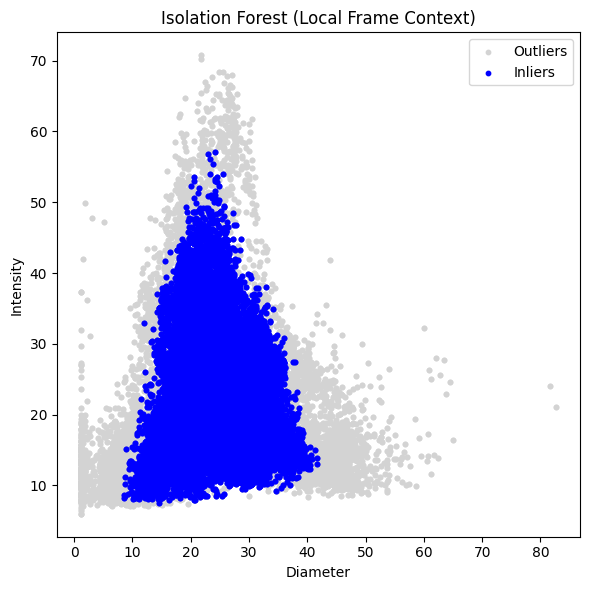

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(df_window_filtered['equivalent_diameter'], df_window_filtered['mean_intensity'], c='lightgray', s=10, label='Outliers')
plt.scatter(df_window_filtered[df_window_filtered['is_inlier']]['equivalent_diameter'], df_window_filtered[df_window_filtered['is_inlier']]['mean_intensity'],
            c='blue', s=10, label='Inliers')
plt.xlabel('Diameter')
plt.ylabel('Intensity')
plt.legend()
plt.title("Isolation Forest (Local Frame Context)")
plt.tight_layout()
output_path = "filtering.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

In [31]:
# === Filter DataFrame based on inlier mask ===
df_all = pd.DataFrame(all_points)
df_filtered = df_all[inlier_mask].reset_index(drop=True)
df_features = df_clean[inlier_mask]


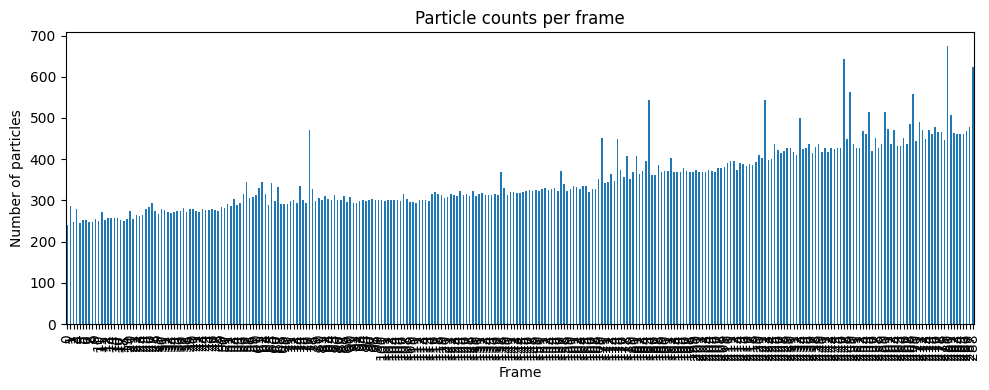

frame
0      240
1      286
2      248
3      280
4      246
      ... 
284    462
285    462
286    468
287    478
288    624
Name: count, Length: 289, dtype: int64


<Figure size 640x480 with 0 Axes>

In [38]:
#Count number of particles in each frame
frame_counts = full_df['frame'].value_counts().sort_index()

# Plot number of features per frame
plt.figure(figsize=(10, 4))
frame_counts.plot(kind='bar')
plt.xlabel('Frame')
plt.ylabel('Number of particles')
plt.title('Particle counts per frame')
plt.tight_layout()
plt.show()
output_path = "particle_counts_per_frame3.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(frame_counts)

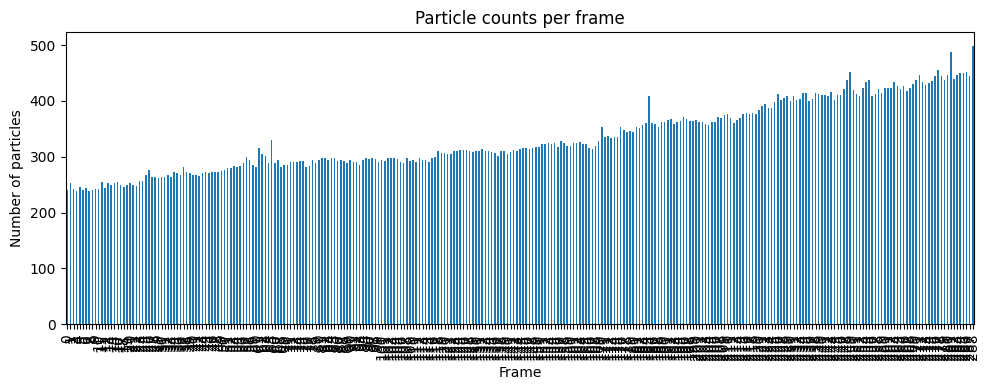

frame
288    498
281    488
277    456
249    452
286    452
Name: count, dtype: int64


In [37]:
#Count number of particles in each frame
frame_counts = tree_df['frame'].value_counts().sort_index()

# Plot number of features per frame
plt.figure(figsize=(10, 4))
frame_counts.plot(kind='bar')
plt.xlabel('Frame')
plt.ylabel('Number of particles')
plt.title('Particle counts per frame')
plt.tight_layout()
output_path = "particle_counts_per_frame2.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(frame_counts.sort_values(ascending=False).head())

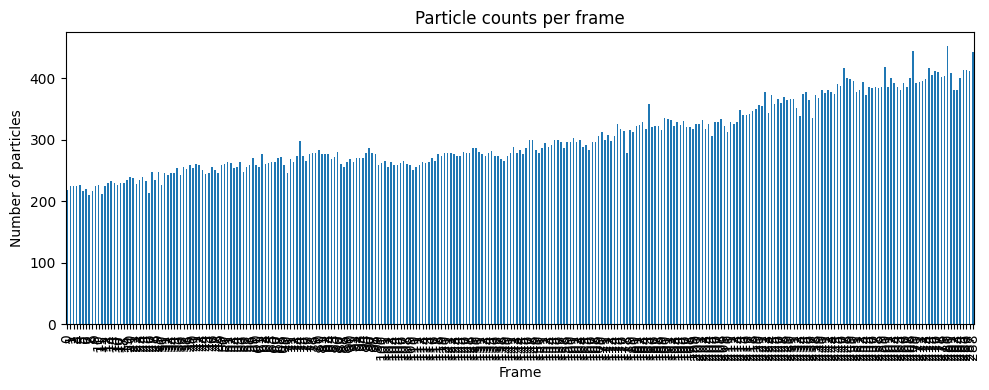

frame
280    452
269    444
288    442
260    418
247    416
Name: count, dtype: int64


In [36]:
#Count number of particles in each frame
frame_counts = df_window_all['frame'].value_counts().sort_index()

# Plot number of features per frame
plt.figure(figsize=(10, 4))
frame_counts.plot(kind='bar')
plt.xlabel('Frame')
plt.ylabel('Number of particles')
plt.title('Particle counts per frame')
plt.tight_layout()
output_path = "particle_counts_per_frame.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(frame_counts.sort_values(ascending=False).head())

In [35]:
linked = tp.link_df(tree_df, search_range=10, memory=3)

Frame 62: 304 trajectories present.


SubnetOversizeException: Subnetwork contains 32 points

In [22]:
ax = tp.plot_traj(linked)
ax.invert_yaxis()
ax.set_title('Tracked trajectories')
ax.set_xlabel('x')
ax.set_ylabel('y')---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
/tmp/ipykernel_42779/28469572.py in ?()
     12 all_points = []
     13 
     14 # === Loop through all image/mask pairs ===
     15 for frame_num, (mask_fname, image_fname) in enumerate(tqdm(zip(mask_files, image_files), total=len(mask_files))):
---> 16     mask = imread(os.path.join(mask_dir, mask_fname))
     17     image = imread(os.path.join(image_dir, image_fname))
     18 
     19     # Convert to grayscale if RGB

~/.pyenv/versions/eql3119/lib/python3.11/site-packages/skimage/_shared/utils.py in ?(*args, **kwargs)
    324                 elif self.new_name is not None:
    325                     # Assign old value to new one
    326                     kwargs[self.new_name] = deprecated_value
    327 
--> 328             return func(*args, **kwargs)

~/.pyenv/versions/eql3119/lib/python3.11/site-packages/skimage/io/_io.py in ?(fname, as_gray, plugin, **plugin_args)
     78         if fname.lower().endswith(('.tiff', '.tif')):
     79             plugin = 'tifffile'
     80 
     81     with file_or_url_context(fname) as fname, _hide_plugin_deprecation_warnings():
---> 82         img = call_plugin('imread', fname, plugin=plugin, **plugin_args)
...
  13746 
  13747         if not result.dtype.isnative:
  13748             if not dtype.isnative:

ValueError: failed to read 9619764 bytes, got 1305344
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...

SyntaxError: invalid decimal literal (345395425.py, line 7)